In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded=files.upload()


Saving Health_Risk_Classifier_XAI_200k.csv to Health_Risk_Classifier_XAI_200k.csv


In [4]:
df=pd.read_csv("/content/Health_Risk_Classifier_XAI_200k.csv")


In [5]:
df.head()

,Age,Gender,BMI,HeartRate,SystolicBP,DiastolicBP,BloodSugar,Cholesterol,Smoking,Alcohol,ExerciseHours,SleepHours,StressLevel,FamilyHistory,RiskLevel
0,69,Male,27.1,75,173,100,111,307,1,1,3.2,8.3,7,0,Medium
1,32,Female,33.2,66,101,105,177,314,1,1,2.5,8.2,10,1,High
2,89,Female,23.7,114,138,82,70,244,0,0,0.8,6.5,7,0,Low
3,78,Female,20.8,64,111,106,95,285,0,1,5.1,9.9,10,1,Medium
4,38,Male,24.4,73,139,108,81,304,0,1,0.5,5.5,6,0,Medium


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 15 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Age            200000 non-null  int64  
 1   Gender         200000 non-null  object 
 2   BMI            200000 non-null  float64
 3   HeartRate      200000 non-null  int64  
 4   SystolicBP     200000 non-null  int64  
 5   DiastolicBP    200000 non-null  int64  
 6   BloodSugar     200000 non-null  int64  
 7   Cholesterol    200000 non-null  int64  
 8   Smoking        200000 non-null  int64  
 9   Alcohol        200000 non-null  int64  
 10  ExerciseHours  200000 non-null  float64
 11  SleepHours     200000 non-null  float64
 12  StressLevel    200000 non-null  int64  
 13  FamilyHistory  200000 non-null  int64  
 14  RiskLevel      200000 non-null  object 
dtypes: float64(3), int64(10), object(2)
memory usage: 22.9+ MB


In [7]:
print("Unique values in Gender:", df['Gender'].unique())
print("Count of each Gender:\n", df['Gender'].value_counts())

print("\nUnique values in RiskLevel:", df['RiskLevel'].unique())
print("Count of each RiskLevel:\n", df['RiskLevel'].value_counts())

Unique values in Gender: ['Male' 'Female']
Count of each Gender:
 Gender
Male      100255
Female     99745
Name: count, dtype: int64

Unique values in RiskLevel: ['Medium' 'High' 'Low']
Count of each RiskLevel:
 RiskLevel
Medium    116787
Low        66263
High       16950
Name: count, dtype: int64


/tmp/ipykernel_518/802548137.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, palette='viridis')
/tmp/ipykernel_518/802548137.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='RiskLevel', data=df, palette='magma')


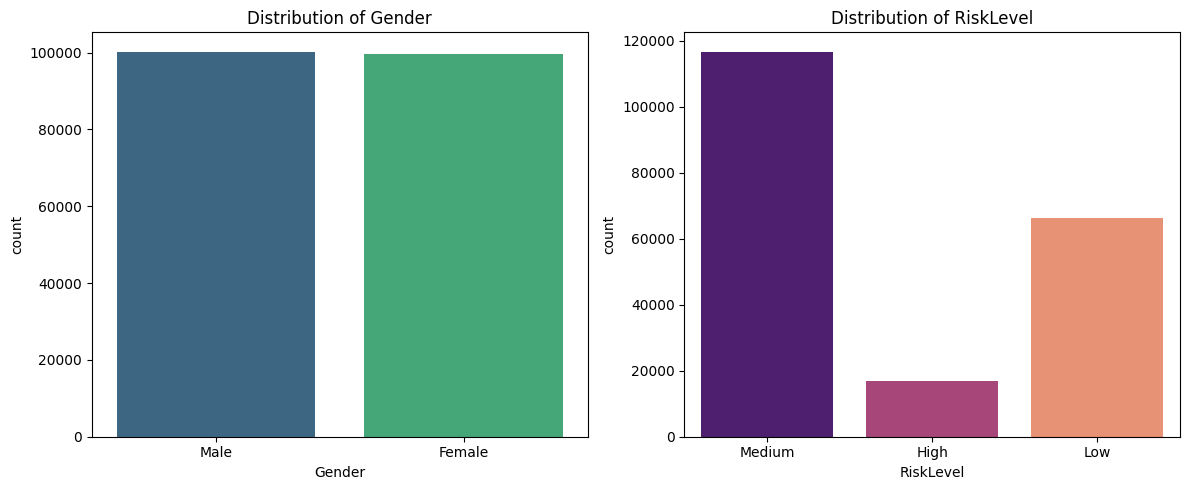

In [8]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='Gender', data=df, palette='viridis')
plt.title('Distribution of Gender')

plt.subplot(1, 2, 2)
sns.countplot(x='RiskLevel', data=df, palette='magma')
plt.title('Distribution of RiskLevel')

plt.tight_layout()
plt.show()

In [9]:
display(df.describe())

,Age,BMI,HeartRate,SystolicBP,DiastolicBP,BloodSugar,Cholesterol,Smoking,Alcohol,ExerciseHours,SleepHours,StressLevel,FamilyHistory
count,200000.000000,200000.000000,200000.00000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,53.916585,26.024283,87.36134,135.094670,84.986150,144.782025,220.023815,0.299910,0.399575,4.986859,7.002035,5.495290,0.350260
std,21.054609,4.951299,19.05708,26.243169,14.727963,43.580719,58.014430,0.458219,0.489812,2.885487,1.731977,2.868907,0.477052
min,18.000000,15.000000,55.00000,90.000000,60.000000,70.000000,120.000000,0.000000,0.000000,0.000000,4.000000,1.000000,0.000000
25%,36.000000,22.600000,71.00000,112.000000,72.000000,107.000000,170.000000,0.000000,0.000000,2.500000,5.500000,3.000000,0.000000
50%,54.000000,26.000000,87.00000,135.000000,85.000000,145.000000,220.000000,0.000000,0.000000,5.000000,7.000000,5.000000,0.000000
75%,72.000000,29.400000,104.00000,158.000000,98.000000,182.000000,270.000000,1.000000,1.000000,7.500000,8.500000,8.000000,1.000000
max,90.000000,45.000000,120.00000,180.000000,110.000000,220.000000,320.000000,1.000000,1.000000,10.000000,10.000000,10.000000,1.000000


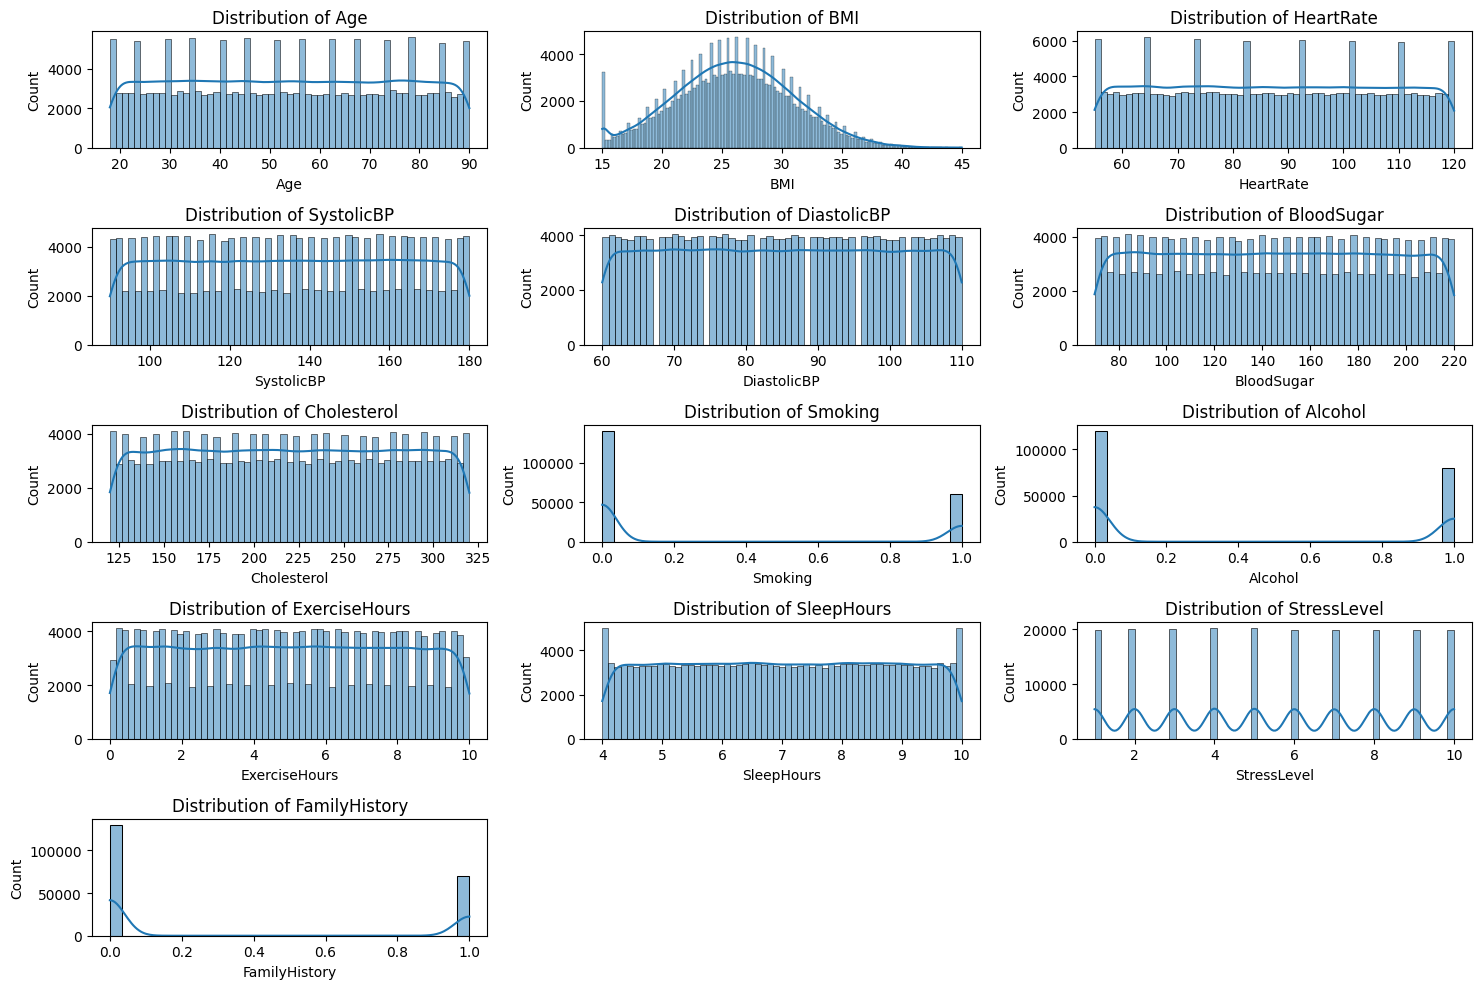

In [14]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15, 10))
num_plots = len(numerical_cols)
rows = (num_plots + 2) // 3

for i, col in enumerate(numerical_cols):
    plt.subplot(rows, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

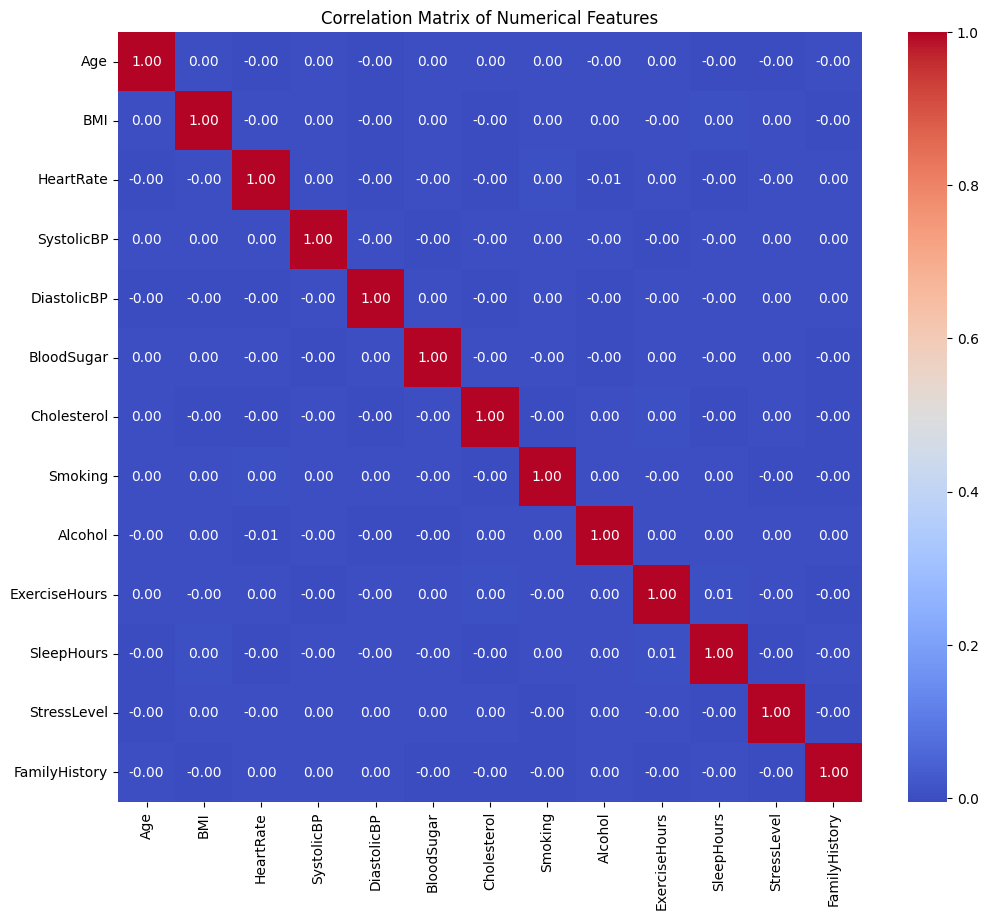

In [11]:
plt.figure(figsize=(12, 10))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [15]:
df_modified = df.drop(columns=['HeartRate'])
print("DataFrame after dropping 'HeartRate':")
display(df_modified.head())

def categorize_bp(row):
    if row['SystolicBP'] > 140 or row['DiastolicBP'] > 90:
        return 'High'
    elif row['SystolicBP'] < 90 or row['DiastolicBP'] < 60:
        return 'Low'
    else:
        return 'Normal'

df_modified['BP_Category'] = df_modified.apply(categorize_bp, axis=1)
print("\nDataFrame after adding 'BP_Category':")
display(df_modified.head())

print("Value counts for the new 'BP_Category' column:")
display(df_modified['BP_Category'].value_counts())

DataFrame after dropping 'HeartRate':


,Age,Gender,BMI,SystolicBP,DiastolicBP,BloodSugar,Cholesterol,Smoking,Alcohol,ExerciseHours,SleepHours,StressLevel,FamilyHistory,RiskLevel
0,69,Male,27.1,173,100,111,307,1,1,3.2,8.3,7,0,Medium
1,32,Female,33.2,101,105,177,314,1,1,2.5,8.2,10,1,High
2,89,Female,23.7,138,82,70,244,0,0,0.8,6.5,7,0,Low
3,78,Female,20.8,111,106,95,285,0,1,5.1,9.9,10,1,Medium
4,38,Male,24.4,139,108,81,304,0,1,0.5,5.5,6,0,Medium



DataFrame after adding 'BP_Category':


,Age,Gender,BMI,SystolicBP,DiastolicBP,BloodSugar,Cholesterol,Smoking,Alcohol,ExerciseHours,SleepHours,StressLevel,FamilyHistory,RiskLevel,BP_Category
0,69,Male,27.1,173,100,111,307,1,1,3.2,8.3,7,0,Medium,High
1,32,Female,33.2,101,105,177,314,1,1,2.5,8.2,10,1,High,High
2,89,Female,23.7,138,82,70,244,0,0,0.8,6.5,7,0,Low,Normal
3,78,Female,20.8,111,106,95,285,0,1,5.1,9.9,10,1,Medium,High
4,38,Male,24.4,139,108,81,304,0,1,0.5,5.5,6,0,Medium,High


Value counts for the new 'BP_Category' column:


,count
BP_Category,
High,131917
Normal,68083


In [28]:
from sklearn.ensemble import RandomForestClassifier

In [36]:
X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)

global rf_train_cols
rf_train_cols = X_train_encoded.columns

missing_in_test = set(rf_train_cols) - set(X_test_encoded.columns)
for c in missing_in_test:
    X_test_encoded[c] = 0


missing_in_train = set(X_test_encoded.columns) - set(rf_train_cols)
for c in missing_in_train:
    X_train_encoded[c] = 0

X_test_encoded = X_test_encoded[rf_train_cols]


rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')


rf_clf.fit(X_train_encoded, y_train)

print("Random Forest model training complete.")

Random Forest model training complete.


Random Forest Accuracy: 0.9748

Random Forest Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.71      0.83      3427
         Low       1.00      1.00      1.00     13100
      Medium       0.96      1.00      0.98     23473

    accuracy                           0.97     40000
   macro avg       0.99      0.90      0.94     40000
weighted avg       0.98      0.97      0.97     40000


Random Forest Confusion Matrix:


,High,Low,Medium
High,2435,0,992
Low,0,13094,6
Medium,1,8,23464


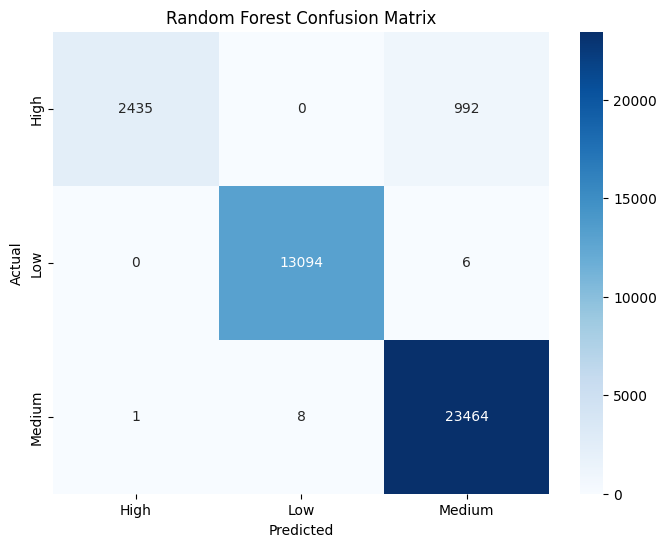

In [37]:
y_pred_rf = rf_clf.predict(X_test_encoded)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

print("\nRandom Forest Confusion Matrix:")
cm_rf = confusion_matrix(y_test, y_pred_rf)
display(pd.DataFrame(cm_rf, index=le.classes_, columns=le.classes_))

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [38]:

new_data_point_encoded = pd.get_dummies(new_data_point)

for col in rf_train_cols:
    if col not in new_data_point_encoded.columns:
        new_data_point_encoded[col] = 0
new_data_point_encoded = new_data_point_encoded[rf_train_cols]

new_prediction_encoded_rf = rf_clf.predict(new_data_point_encoded)
new_prediction_label_rf = le.inverse_transform(new_prediction_encoded_rf)

print(f"\nPredicted RiskLevel for the new data point using Random Forest: {new_prediction_label_rf[0]}")

new_prediction_proba_rf = rf_clf.predict_proba(new_data_point_encoded)
proba_df_rf = pd.DataFrame(new_prediction_proba_rf, columns=le.classes_)

print("\nRandom Forest Prediction Probabilities:")
display(proba_df_rf)


Predicted RiskLevel for the new data point using Random Forest: Low

Random Forest Prediction Probabilities:


,High,Low,Medium
0,0.0,1.0,0.0


In [23]:
new_data_point = pd.DataFrame({
    'Age': [50],
    'Gender': ['Female'],
    'BMI': [25.5],
    'HeartRate': [70],
    'SystolicBP': [120],
    'DiastolicBP': [80],
    'BloodSugar': [100],
    'Cholesterol': [200],
    'Smoking': [0],
    'Alcohol': [0],
    'ExerciseHours': [5.0],
    'SleepHours': [7.0],
    'StressLevel': [4],
    'FamilyHistory': [0]
})

for col in categorical_features:
    if col in new_data_point.columns:
        new_data_point[col] = new_data_point[col].astype('category')


print("Sample new data point:")
display(new_data_point)

new_prediction_encoded = lgbm_clf.predict(new_data_point)

new_prediction_label = le.inverse_transform(new_prediction_encoded)

print(f"\nPredicted RiskLevel for the new data point: {new_prediction_label[0]}")

new_prediction_proba = lgbm_clf.predict_proba(new_data_point)
proba_df = pd.DataFrame(new_prediction_proba, columns=le.classes_)

print("\nPrediction Probabilities:")
display(proba_df)

Sample new data point:


,Age,Gender,BMI,HeartRate,SystolicBP,DiastolicBP,BloodSugar,Cholesterol,Smoking,Alcohol,ExerciseHours,SleepHours,StressLevel,FamilyHistory
0,50,Female,25.5,70,120,80,100,200,0,0,5.0,7.0,4,0



Predicted RiskLevel for the new data point: Low

Prediction Probabilities:


,High,Low,Medium
0,0.000003,0.999993,0.000004


In [32]:
joblib.dump(rf_clf, 'Random_Forest_Health_Risk_Classifier.joblib')
print("Random Forest model saved as 'Random_Forest_Health_Risk_Classifier.joblib'")

Random Forest model saved as 'Random_Forest_Health_Risk_Classifier.joblib'
